In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

In [ ]:
def species_threshold(target_species: int) -> rd.Expr:
    GAIN = 0.3
    target = float(max(target_species, 1))

    count_error = (
        rd.select("count.species").rolling(target_species).mean() - target
    ) / target

    step = (count_error * GAIN + 1.0).clamp(0.8, 1.5)
    prev = rd.select("species.threshold").last()

    result = (prev * step).clamp(0.005, 2.0)
    return result


target_species = 7.0
rolling = int(target_species)
result = species_threshold(rolling)
dist_signal = species_threshold(rolling)

rolling_species_count = rd.select("count.species").rolling(25).mean()


In [ ]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(rd.NeatDistance(), result)
    .metrics(
        dist_signal=dist_signal,
        species_rolling=rolling_species_count,
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-05-31T19:37:47.481794Z  INFO Epoch 1    | Score:   2.0038 | Time: 215.42µs
2026-05-31T19:37:47.481941Z  INFO Epoch 2    | Score:   1.6821 | Time: 319.79µs
2026-05-31T19:37:47.482087Z  INFO Epoch 3    | Score:   1.6821 | Time: 424.13µs
2026-05-31T19:37:47.482254Z  INFO Epoch 4    | Score:   1.6821 | Time: 552.92µs
2026-05-31T19:37:47.482480Z  INFO Epoch 5    | Score:   1.6820 | Time: 729.17µs
2026-05-31T19:37:47.482743Z  INFO Epoch 6    | Score:   1.6820 | Time: 938.13µs
2026-05-31T19:37:47.483047Z  INFO Epoch 7    | Score:   1.6820 | Time: 1.19ms
2026-05-31T19:37:47.483403Z  INFO Epoch 8    | Score:   1.6820 | Time: 1.48ms
2026-05-31T19:37:47.483609Z  INFO Epoch 9    | Score:   1.4901 | Time: 1.64ms
2026-05-31T19:37:47.483869Z  INFO Epoch 10   | Score:   1.4408 | Time: 1.82ms
2026-05-31T19:37:47.484185Z  INFO Epoch 11   | Score:   1.4058 | Time: 2.06ms
2026-05-31T19:37:47.484500Z  INFO Epoch 12   | Score:   1.4058 | Time: 2.32ms
2026-05-31T19:37:47.484826Z  INFO Epoch 13   | Score

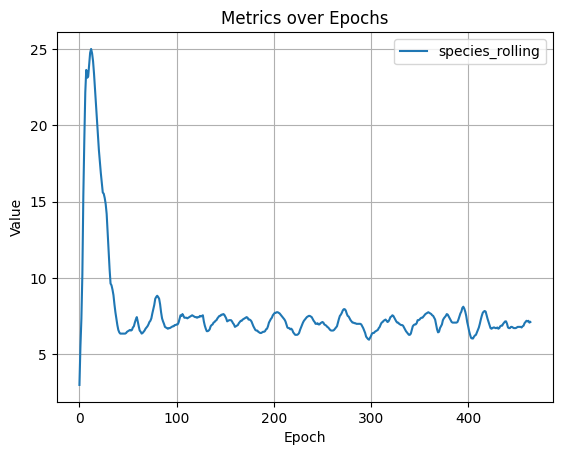

In [ ]:
collector.plot("species_rolling")

In [6]:
df = collector.to_polars()
df.filter(pl.col("name") == "count.species")

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.species""",3.0,3.0,3.0,0.0,0.0,NaN,3.0,3.0,1,null,null,null,null,null,null,0,1,"[""species"", ""statistic""]"
"""count.species""",8.0,11.0,5.5,3.535534,12.5,NaN,3.0,8.0,2,null,null,null,null,null,null,1,1,"[""species"", ""statistic""]"
"""count.species""",11.0,22.0,7.333333,4.041452,16.333334,-1.532828,3.0,11.0,3,null,null,null,null,null,null,2,1,"[""species"", ""statistic""]"
"""count.species""",19.0,41.0,10.25,6.70199,44.916668,0.991255,3.0,19.0,4,null,null,null,null,null,null,3,1,"[""species"", ""statistic""]"
"""count.species""",36.0,77.0,15.4,12.895736,166.300003,1.755211,3.0,36.0,5,null,null,null,null,null,null,4,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.species""",10.0,3473.0,7.533623,4.939356,24.397238,3.171057,1.0,41.0,461,null,null,null,null,null,null,460,1,"[""species"", ""statistic""]"
"""count.species""",10.0,3483.0,7.538961,4.93533,24.357481,3.169015,1.0,41.0,462,null,null,null,null,null,null,461,1,"[""species"", ""statistic""]"
"""count.species""",12.0,3495.0,7.548596,4.934343,24.347742,3.159512,1.0,41.0,463,null,null,null,null,null,null,462,1,"[""species"", ""statistic""]"


In [7]:
df = collector.to_polars()
df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.evaluation""",8.0,108.0,54.0,65.053825,4232.0,NaN,8.0,100.0,2,null,null,null,null,null,null,0,2,"[""statistic""]"
"""step.evaluate.time""",0.00001,0.000071,0.000036,0.000036,1.2730e-9,NaN,0.00001,0.000061,2,71µs,35µs,35µs,10µs,60µs,0µs,0,2,"[""time"", ""step""]"
"""selector.roulette""",20.0,20.0,20.0,0.0,0.0,NaN,20.0,20.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
"""selector.roulette.time""",0.000007,0.000007,0.000007,0.0,0.0,NaN,0.000007,0.000007,1,6µs,6µs,0µs,6µs,6µs,0µs,0,1,"[""selector"", ""time""]"
"""selector.tournament""",80.0,80.0,80.0,0.0,0.0,NaN,80.0,80.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""score.improvement""",1.0,67.0,1.0,0.0,0.0,0.0,1.0,1.0,67,null,null,null,null,null,null,464,1,"[""statistic"", ""score""]"
"""scores.best""",0.000581,86.724945,0.186505,0.331383,0.109815,0.0,0.000581,2.003778,465,null,null,null,null,null,null,464,1,"[""statistic"", ""score""]"
"""dist_signal""",0.085792,92.742798,0.199447,0.204386,0.041774,0.0,0.005,1.916221,465,null,null,null,null,null,null,464,1,"[""statistic"", ""expr""]"


In [8]:
print(result.index())
last_version = df.select("generation").max().item()
last_version

465


464